<a href="https://colab.research.google.com/github/Aarya-Musale/Machine-Learning/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
path = "/content/banknotes.csv"

In [ ]:
bn = pd.read_csv(path)
bn.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
bn.shape

(1372, 5)

In [ ]:
bn.isna().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [ ]:
bn.dtypes

,0
Variance,float64
Skewness,float64
Curtosis,float64
Entropy,float64
Class,int64


In [ ]:
bn['Class'].value_counts()

,count
Class,
0,762
1,610


In [ ]:
bn['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,55.539359
1,44.460641


/tmp/ipykernel_1400/2387831168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=bn, x='Class', palette='Set2')


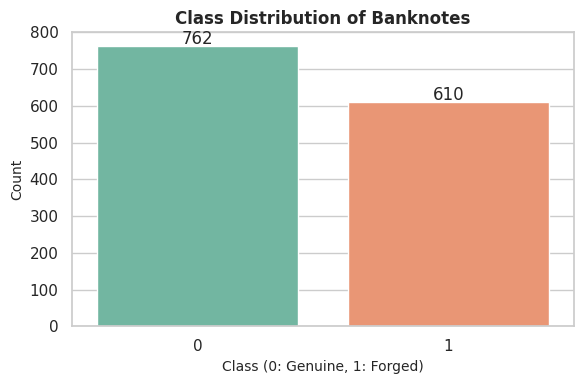

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=bn, x='Class', palette='Set2')

plt.title('Class Distribution of Banknotes', fontsize=12, fontweight='bold')
plt.xlabel('Class (0: Genuine, 1: Forged)', fontsize=10)
plt.ylabel('Count', fontsize=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

**Using Gini**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
clf = DecisionTreeClassifier(random_state=42)


clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy and print reports
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9818181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       148
           1       1.00      0.96      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275


Confusion Matrix:
 [[148   0]
 [  5 122]]


In [ ]:
for feature, importance in zip(X.columns, clf.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Variance: 0.6223
Skewness: 0.2229
Curtosis: 0.1415
Entropy: 0.0134


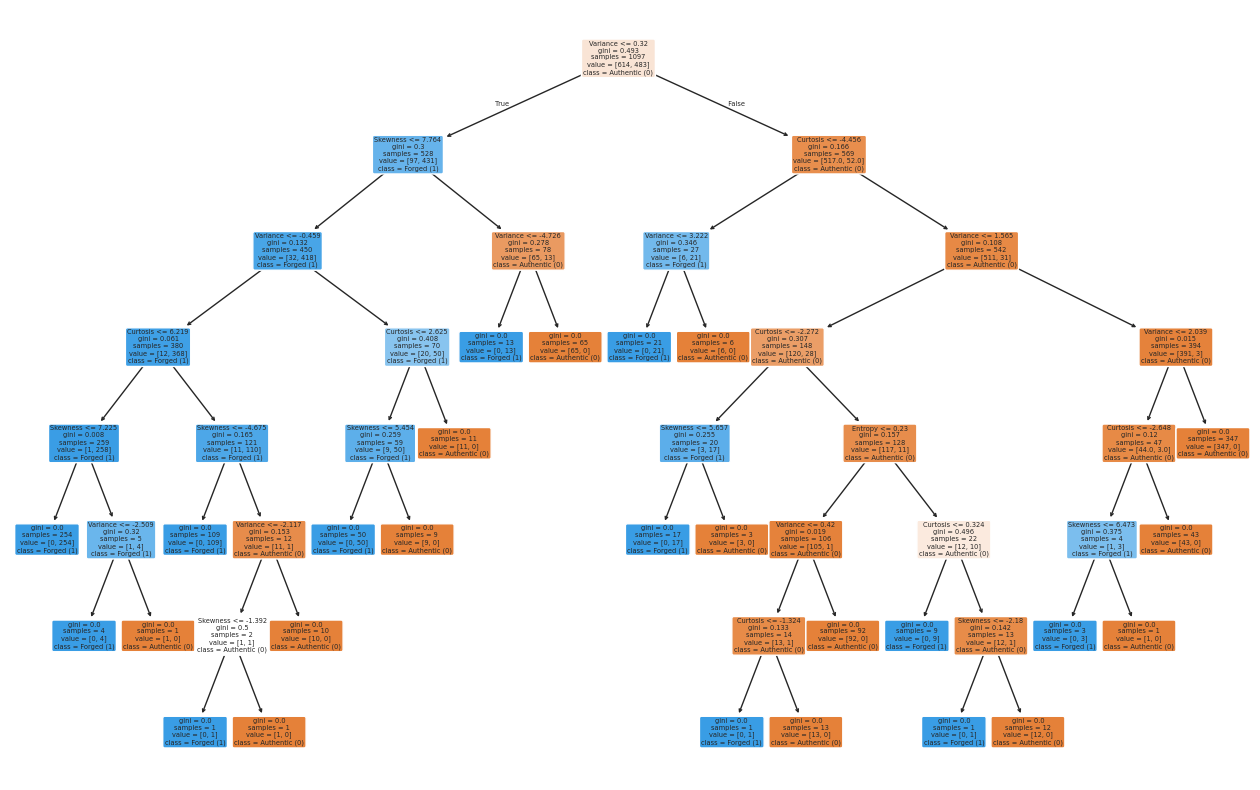

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))
plot_tree(clf, feature_names=X.columns, class_names=['Authentic (0)', 'Forged (1)'], filled=True, rounded=True)
plt.show()

**Using Entropy**

In [ ]:
# Initialize the Decision Tree Classifier with Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train the model on the training set
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on the test set
y_pred_entropy = clf_entropy.predict(X_test)

# Print evaluation metrics
print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_entropy))

Entropy Accuracy: 0.9854545454545455

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       148
           1       1.00      0.97      0.98       127

    accuracy                           0.99       275
   macro avg       0.99      0.98      0.99       275
weighted avg       0.99      0.99      0.99       275



In [ ]:
print("Feature Importances (Entropy):")
for feature, importance in zip(X.columns, clf_entropy.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Feature Importances (Entropy):
Variance: 0.5983
Skewness: 0.2317
Curtosis: 0.1466
Entropy: 0.0234


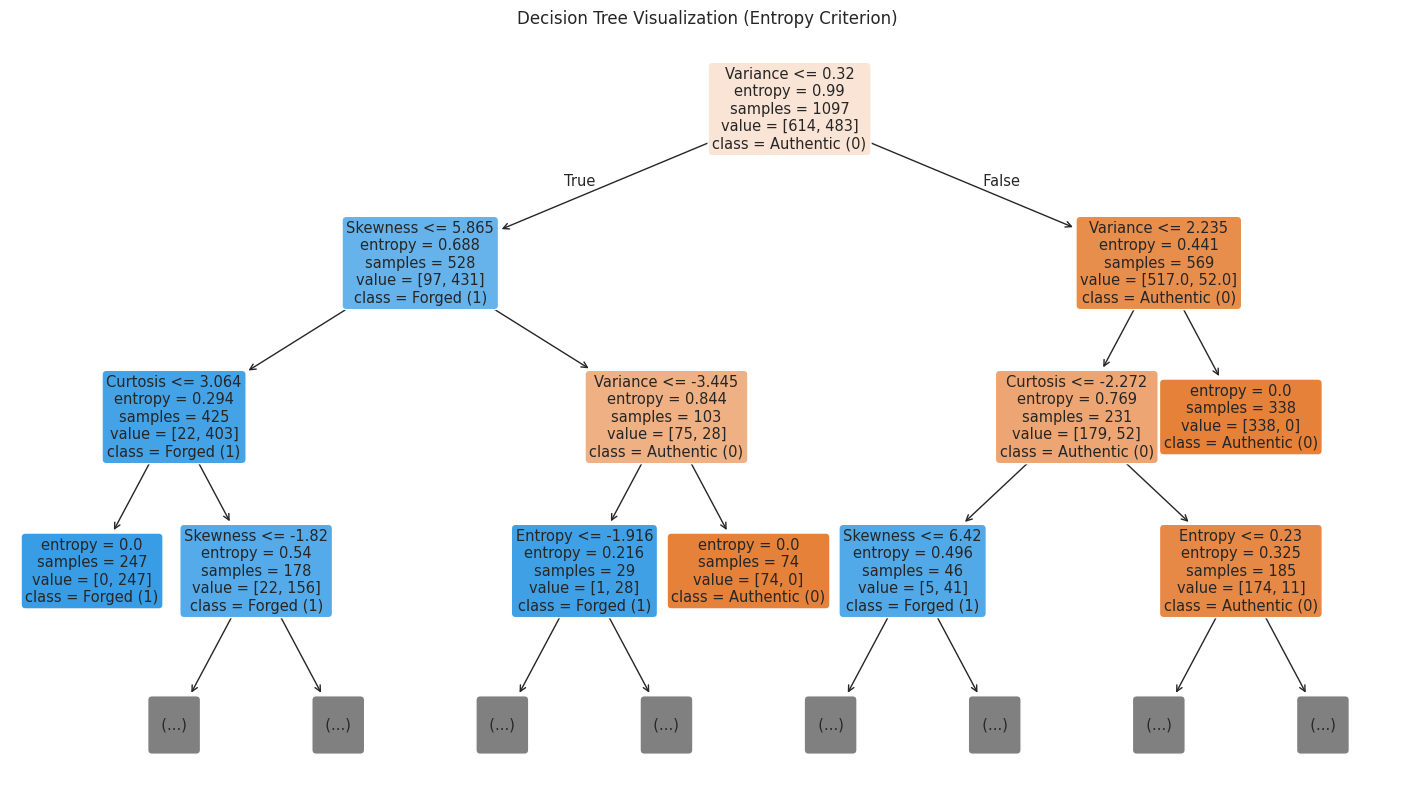

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set up the plot figure size
plt.figure(figsize=(18, 10))

# Plot the tree
plot_tree(
    clf_entropy,
    feature_names=X.columns,
    class_names=['Authentic (0)', 'Forged (1)'],
    filled=True,
    rounded=True,
    max_depth=3  # Truncates the tree to depth 3 for better readability
)

plt.title("Decision Tree Visualization (Entropy Criterion)")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# 1. Gini Score
y_pred_gini = clf.predict(X_test) # or clf_gini
gini_score = accuracy_score(y_test, y_pred_gini)
print(f"Gini Score: {gini_score:.4f}")

# 2. Entropy Score
y_pred_entropy = clf_entropy.predict(X_test)
entropy_score = accuracy_score(y_test, y_pred_entropy)
print(f"Entropy Score: {entropy_score:.4f}")

Gini Score: 0.9818
Entropy Score: 0.9855


In [ ]:
import joblib

joblib.dump(clf, 'banknote_model.pkl')
print("Model trained and saved successfully as 'banknote_model.pkl'!")

Model trained and saved successfully as 'banknote_model.pkl'!
